# MSAAD — end-to-end tutorial

A narrated walkthrough of
[Burks et al., *Algorithms* 2025](https://doi.org/10.3390/a18090577), run
entirely on **synthetic** data. We cover:

1. the MSAAD algorithm (it's ~3 lines),
2. reading the 1/fᵝ spectral exponent off the MSAAD slope,
3. stability & speed vs. sample entropy,
4. separating **diabetes** cohorts in skin temperature,
5. **critical slowing down** with age — scale- and sex-dependent.

> The synthetic data plants effects into the signal's *fluctuation structure*,
> so recovering them validates the estimators — not human physiology.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from msaad import msaad, aad, coarse_grain, loglog_slope, beta_from_slope, powerlaw_noise
from msaad.baselines import multiscale, sample_entropy
from msaad import plotting as viz
from msaad.config import MSAADConfig, NOISE_BETAS, NOISE_LABELS
viz.apply_style()
config = MSAADConfig()
DATA = "synthetic_demo"  # written next to this notebook

## 1. The algorithm
AAD is just the mean absolute first difference; MSAAD applies it after coarse-graining at each scale. Note the exact identity the paper points out:

In [2]:
x = np.array([1, 2, 1, 20, 20, 20, 1.0])
print("AAD(x)           =", aad(x))
print("mean(|diff(x)|)  =", np.mean(np.abs(np.diff(x))))
print("coarse_grain(x,2)=", coarse_grain(x, 2))

AAD(x)           = 6.666666666666667
mean(|diff(x)|)  = 6.666666666666667
coarse_grain(x,2)= [ 1.5 10.5 20. ]


## 2. MSAAD of the five noise colours
On log–log axes the MSAAD curve is a straight line whose slope encodes the spectral exponent β.

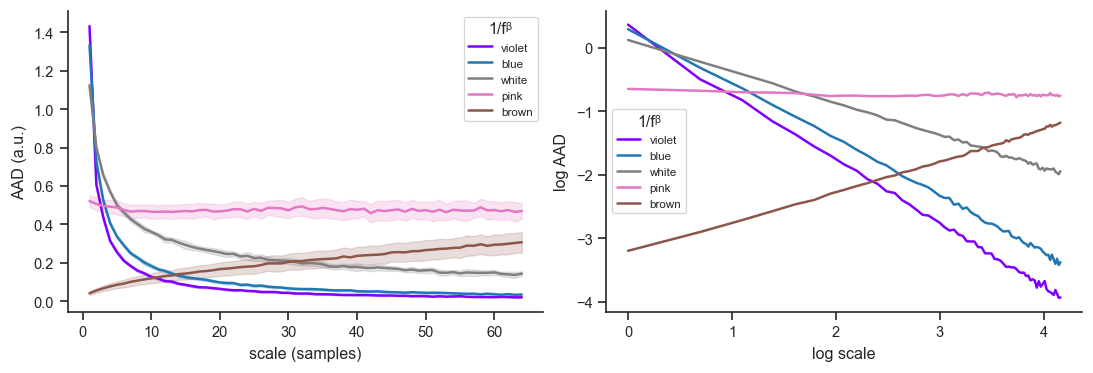

In [3]:
rng = np.random.default_rng(0)
scales = np.arange(1, 65)
curves = {b: np.array([msaad(powerlaw_noise(b, 2**12, rng=rng), scales) for _ in range(20)])
          for b in NOISE_BETAS}

fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")
viz.plot_noise_curves(curves, scales, ax=axes[0], log=False)
viz.plot_noise_curves(curves, scales, ax=axes[1], log=True)
plt.show()

## 3. Read β off the slope
`beta_from_slope` inverts the paper's empirical law `slope ≈ 0.48·β − 0.48` to estimate the spectral exponent — a cheap alternative to spectral fitting.

In [4]:
for b in NOISE_BETAS:
    sl = np.mean([loglog_slope(msaad(powerlaw_noise(b, 2**13, rng=rng), scales), scales)
                  for _ in range(10)])
    print(f"{NOISE_LABELS[b]:>7} (β={b:+d}):  slope={sl:+.2f}  →  β̂={beta_from_slope(sl):+.2f}")

 violet (β=-2):  slope=-1.01  →  β̂=-1.10
   blue (β=-1):  slope=-0.89  →  β̂=-0.85
  white (β=+0):  slope=-0.50  →  β̂=-0.04
   pink (β=+1):  slope=-0.01  →  β̂=+0.98
  brown (β=+2):  slope=+0.48  →  β̂=+2.01


## 4. Faster and more stable than sample entropy
MSAAD averages over the whole distribution of fluctuations, so its curve is more consistent across realizations — and it is an order of magnitude cheaper.

In [5]:
import time
batch = rng.standard_normal((60, 1440)); sc = np.arange(1, 121)
t=time.perf_counter(); [msaad(s, sc) for s in batch]; t_ms=time.perf_counter()-t
t=time.perf_counter(); [multiscale(s, sample_entropy, sc) for s in batch]; t_se=time.perf_counter()-t
print(f"MSAAD: {t_ms:.2f}s | SampEn: {t_se:.2f}s | speedup ≈ {t_se/t_ms:.0f}×")

MSAAD: 0.08s | SampEn: 11.97s | speedup ≈ 152×


## 5. Separating diabetes cohorts
Generate a synthetic cohort, extract each participant's summed-MSAAD feature, and compare DM vs No-DM (ages 45–65) by sex. The effect **reverses between awake and asleep** — the paper's surprising result.

In [6]:
from msaad.synthetic import generate_dataset
from msaad.pipeline import extract_diabetes_features
from msaad.io import load_demographics
from msaad.cohorts import compare_diabetes_cohorts

demo = generate_dataset(300, DATA, n_days=6, seed=42)
feats = extract_diabetes_features(DATA, config=config, progress=False)
feats = feats.merge(demo, left_on="pid", right_index=True)
cohort = feats[(feats.age >= 45) & (feats.age <= 65)]

for state in ["awake", "asleep"]:
    res = compare_diabetes_cohorts(cohort[cohort.state == state])
    dm, df_ = res.cohens_d["No-DM_male_vs_DM_male"], res.cohens_d["No-DM_female_vs_DM_female"]
    print(f"{state:>7}: Kruskal p={res.kruskal_p:.1e} | Cohen d (No-DM−DM) male={dm:+.2f} female={df_:+.2f}")

  awake: Kruskal p=8.1e-02 | Cohen d (No-DM−DM) male=+0.44 female=+0.90
 asleep: Kruskal p=3.8e-03 | Cohen d (No-DM−DM) male=-0.87 female=-1.49


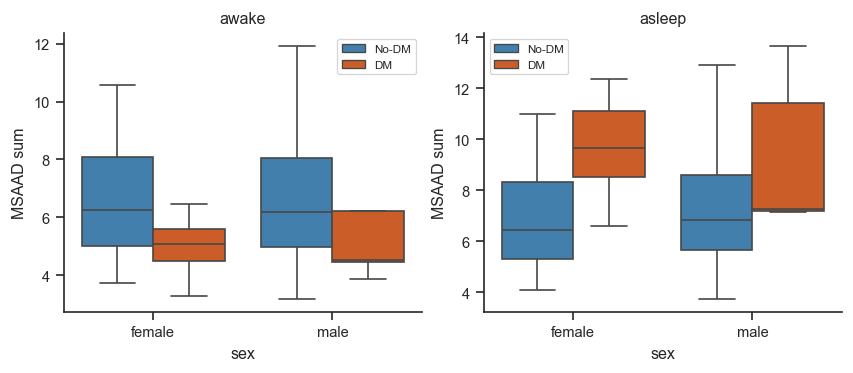

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3), layout="constrained")
for ax, state in zip(axes, ["awake", "asleep"]):
    viz.plot_diabetes_boxplot(cohort[cohort.state == state], ax=ax); ax.set_title(state)
plt.show()

## 6. Critical slowing down with age
Correlate AAD with age **at each scale**, by sex. Negative ρ = variability declines with age; the effect concentrates at short scales for men and long scales for women.

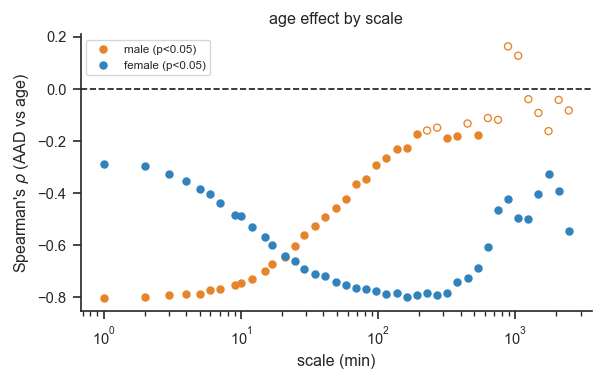

In [8]:
from msaad.pipeline import extract_age_features
from msaad.cohorts import age_scale_spearman

agef = extract_age_features(DATA, config=config, progress=False).join(demo)
scales_age = np.asarray(config.age_scales)
by_sex = {}
for sex in ["male", "female"]:
    s = agef[agef.sex == sex]
    by_sex[sex] = age_scale_spearman(s[[f"s{x}" for x in scales_age]].to_numpy(),
                                     s.age.to_numpy(), scales_age)

fig, ax = plt.subplots(figsize=(5.5, 3))
viz.plot_age_spearman(by_sex, ax=ax); plt.show()

## Takeaway

MSAAD is a three-line, parameter-free complexity feature that (1) recovers the
spectral exponent of 1/fᵝ noise, (2) is stabler and ~10× faster than sample
entropy, and (3) surfaces diabetes- and age-related structure in skin temperature
that the classical metrics miss. See the paper and `docs/METHODS.md` for detail.